In [1]:
import pathlib
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from skimage.feature import hog

In [2]:
# data_dir = pathlib.Path('./output_new_data_temporal/rgb')
data_dir = pathlib.Path('./output_new_data_temporal_no_radius_adjust/rgb')
image_count = len(list(data_dir.glob('*.jpg')))
print(image_count)

344


In [3]:
def hog_feature_vector(src, pixels_per_cell):
    fd = hog(src, orientations=9, pixels_per_cell=pixels_per_cell, cells_per_block=(1, 1), channel_axis=2)
    # fd = hog(src, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(3, 3), channel_axis=2)
    return fd

def image_enhance(src):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
    # Top Hat Transform
    topHat = cv2.morphologyEx(src, cv2.MORPH_TOPHAT, kernel)
    # Black Hat Transform
    blackHat = cv2.morphologyEx(src, cv2.MORPH_BLACKHAT, kernel)
    src = src + topHat - blackHat
    # print('enhance on')
    return src

In [4]:
from sklearn.model_selection import train_test_split

experiment_with_gray_scale = True

use_entire_dataset = True

enhance = True

load_all_images = False

# pixels_per_cell = (10, 10)
# pixels_per_cell = (20, 20)
# pixels_per_cell = (50, 50)
pixels_per_cell = (100, 100)
# pixels_per_cell = (125, 125)

# Data selection
molecular_imprinting_name, load_all_images = 'all', True
# molecular_imprinting_name = 'C4'
# molecular_imprinting_name = 'C6'
# molecular_imprinting_name = 'C8'

image_limit = {
        'C4': 12,
        'C6': 18,
        'C8': 16,
        'all': 12,
    }

images_cache = {}
for path in sorted(data_dir.glob('*.jpg')):
    solution_name = path.name.split('-')[0]
    ion_name = path.name.split('-')[2]
    sequence_name = path.name.split('-')[-2]
    frame_name = path.name.split('-')[-1].split('.')[0]
    if not load_all_images and solution_name != molecular_imprinting_name:
        continue
    
    src = cv2.imread(str(path))
    if experiment_with_gray_scale:
        src = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)
        src = cv2.cvtColor(src, cv2.COLOR_GRAY2RGB)
    else:
        src = cv2.cvtColor(src, cv2.COLOR_BGR2RGB)
    height, width = src.shape[:2]
    center = (width / 2, height / 2)
    if enhance:
        src = image_enhance(src)
    
    identity = solution_name + '-' + ion_name + '-' + sequence_name
    if identity not in images_cache:
        images_cache[identity] = {}
    if int(frame_name) < image_limit[molecular_imprinting_name]:
        images_cache[identity][frame_name] = src


In [5]:
x = []
y = []

for identity, frames in images_cache.items():
    sorted_frames = sorted(frames.keys(), key=lambda x: int(x))
    feature_vector = []

    for i in range(len(sorted_frames) - 1):
        diff_image = cv2.absdiff(frames[sorted_frames[i]], frames[sorted_frames[i + 1]])
        feature_vector.append(hog_feature_vector(diff_image, pixels_per_cell))

    assert len(feature_vector) == image_limit[molecular_imprinting_name] - 1
    
    feature_vector = np.array(feature_vector)
    feature_vector = feature_vector.reshape(-1)
    
    if load_all_images:
        label_name = identity.split('-')[0] + identity.split('-')[1]
    else:
        label_name = identity.split('-')[1]
        
    # filter
    if label_name[-2:] == 'Br':
        continue
    if label_name[-4:] == 'Tf2N':
        continue
    
    x.append(feature_vector)
    y.append(label_name)

In [6]:
x = np.array(x)
y = np.array(y)
print('data loaded x=%i' % (len(x)))
print('data loaded y=%i' % (len(y)))
print('x.shape=%s' % (str(x.shape)))
print('y.shape=%s' % (str(y.shape)))

data loaded x=13
data loaded y=13
x.shape=(13, 9900)
y.shape=(13,)


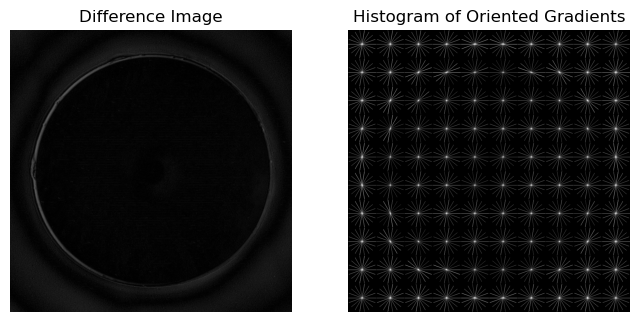

In [7]:
import matplotlib.pyplot as plt
from skimage import exposure

# Select an identity
identity = list(images_cache.keys())[0]

# Get the sorted frame keys
sorted_frames = sorted(images_cache[identity].keys(), key=lambda x: int(x))

# Calculate the difference between the first two frames
diff_image = cv2.absdiff(images_cache[identity][sorted_frames[0]], images_cache[identity][sorted_frames[1]])

# Apply the HOG feature extraction
fd, hog_image = hog(diff_image, orientations=9, pixels_per_cell=pixels_per_cell, cells_per_block=(1, 1), visualize=True, channel_axis=2)

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 1))

# Visualize the original difference image and the HOG image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.axis('off')
ax1.imshow(cv2.cvtColor(diff_image, cv2.COLOR_BGR2RGB))
ax1.set_title('Difference Image')

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')

plt.show()

(10, 10, 1, 1, 8)


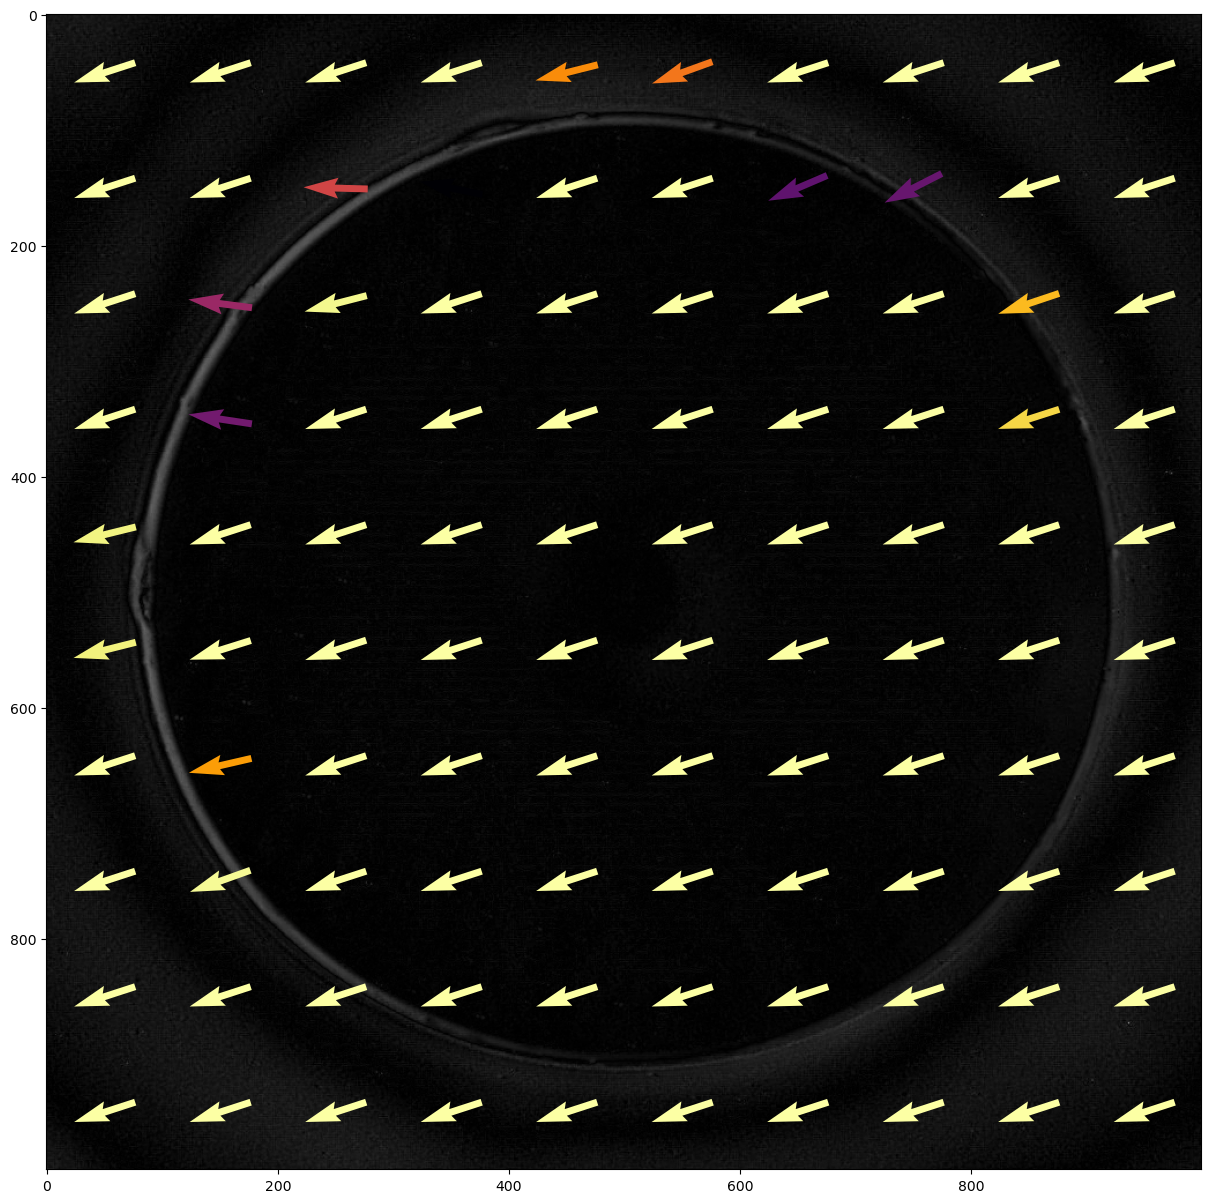

In [8]:
from sklearn import preprocessing as p
import matplotlib.cm as cm
from matplotlib.colors import Normalize

fd, hog_image = hog(diff_image, orientations=8, pixels_per_cell=pixels_per_cell, cells_per_block=(1, 1), visualize=True, channel_axis=2, feature_vector=False)

print(fd.shape)

fig = plt.figure(figsize=(15, 15))
# plt.axis('off')
x_loc_array = []
y_loc_array = []
unit_vector_x_array = []
unit_vector_y_array = []
colors_array = []
colormap = cm.inferno
for i in range(10):
    for j in range(10):
        feature = fd[i][j][0][0]
        x_loc = 50 + i * 100
        y_loc = 50 + j * 100
        final_radian = 0
        sum_feat = 0
        for k in range(len(feature)):
            angle_in_radian = (np.pi / 9) * k
            final_radian += angle_in_radian * feature[k]
            sum_feat += feature[k]

        unit_vector_x = np.cos(final_radian)
        unit_vector_y = np.sin(final_radian)
        x_loc_array.append(x_loc)
        y_loc_array.append(y_loc)
        unit_vector_x_array.append(unit_vector_x)
        unit_vector_y_array.append(unit_vector_y)
        colors_array.append(sum_feat)

norm = Normalize()
norm.autoscale(colors_array)

plt.quiver(x_loc_array, y_loc_array, unit_vector_x_array, unit_vector_y_array, pivot='middle', color=colormap(norm(colors_array)))
plt.imshow(diff_image)

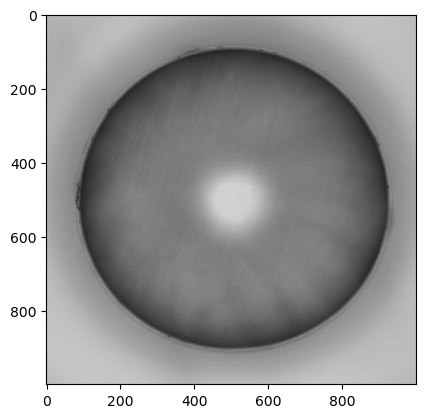

In [9]:
plt.imshow(images_cache[identity][sorted_frames[0]])

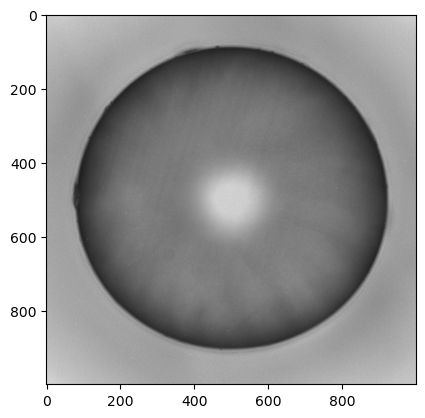

In [10]:
plt.imshow(images_cache[identity][sorted_frames[1]])

In [11]:
# import matplotlib.pyplot as plt
# 
# # Calculate the total number of subplots needed
# total_subplots = sum(len(frames) - 1 for frames in images_cache.values())
# 
# # Create a figure with that many subplots arranged in a grid
# fig, axs = plt.subplots(total_subplots, 3, figsize=(12, 4 * total_subplots))
# 
# # Initialize the subplot index
# subplot_idx = 0
# 
# # Loop over each identity in the images_cache
# for identity, frames in images_cache.items():
#     # Get the sorted frame keys
#     sorted_frames = sorted(frames.keys(), key=lambda x: int(x))
# 
#     # Loop over the sorted frames from 0 to n-1
#     for i in range(len(sorted_frames) - 1):
#         # Calculate the difference between the current frame and the next frame
#         diff_image = cv2.absdiff(frames[sorted_frames[i]], frames[sorted_frames[i + 1]])
# 
#         # Plot the original images and their difference in the next subplot
#         axs[subplot_idx, 0].axis('off')
#         axs[subplot_idx, 0].imshow(cv2.cvtColor(frames[sorted_frames[i]], cv2.COLOR_BGR2RGB))
#         axs[subplot_idx, 0].set_title(f'Original Image {sorted_frames[i]}')
# 
#         axs[subplot_idx, 1].axis('off')
#         axs[subplot_idx, 1].imshow(cv2.cvtColor(frames[sorted_frames[i + 1]], cv2.COLOR_BGR2RGB))
#         axs[subplot_idx, 1].set_title(f'Original Image {sorted_frames[i + 1]}')
# 
#         axs[subplot_idx, 2].axis('off')
#         axs[subplot_idx, 2].imshow(cv2.cvtColor(diff_image, cv2.COLOR_BGR2RGB))
#         axs[subplot_idx, 2].set_title('Difference Image')
# 
#         # Increment the subplot index
#         subplot_idx += 1
# 
# # Display the figure
# plt.tight_layout()
# plt.show()

DATA MINING

In [12]:
from sklearn.manifold import TSNE

from sklearn.preprocessing import StandardScaler
perplexity=3
pca = TSNE(n_components=3, learning_rate='auto', init='pca', perplexity=perplexity)
if use_entire_dataset:
    x_train_pca = pca.fit_transform(x)
    y_train = y
x_train_pca

array([[-133.8695    ,  -85.96937   ,   17.780079  ],
       [ -98.46388   , -106.58445   ,  -36.805256  ],
       [ -23.77913   ,   75.08915   ,   65.89496   ],
       [ -34.134148  ,   13.152264  ,   93.36232   ],
       [ 129.58101   ,  -10.139922  ,    0.44985977],
       [ 134.14772   ,   33.148952  ,   59.185764  ],
       [  47.24268   ,  -76.574196  ,   44.757256  ],
       [   5.258912  ,   24.91549   , -131.88571   ],
       [  29.689898  ,  -54.385597  , -104.747955  ],
       [  46.493492  ,   25.61973   ,  195.07097   ],
       [-147.39226   ,   55.539864  ,   52.550114  ],
       [ -75.230415  ,   66.49959   , -139.39264   ],
       [   1.5388254 ,   68.542     ,  -75.62816   ]], dtype=float32)

In [13]:
import pandas as pd
n_components=3
df = pd.DataFrame(x_train_pca, columns=[f"PC{i + 1}" for i in range(n_components)])
label_list = []

for i in range(len(x_train_pca)):
    label_list.append(y_train[i])
df['label'] = label_list
df

,PC1,PC2,PC3,label
0,-133.869507,-85.969368,17.780079,C4BF4
1,-98.463882,-106.584450,-36.805256,C4BF4
2,-23.779131,75.089149,65.894958,C4PF6
3,-34.134148,13.152264,93.362320,C4PF6
4,129.581009,-10.139922,0.449860,C6BF4
5,134.147720,33.148952,59.185764,C6BF4
6,47.242680,-76.574196,44.757256,C6BF4
7,5.258912,24.915489,-131.885712,C6PF6
8,29.689898,-54.385597,-104.747955,C6PF6
9,46.493492,25.619730,195.070969,C8BF4


In [14]:
import plotly.io as pio

print(pio.templates)
pio.templates.default = 'plotly'

Templates configuration
-----------------------
    Default template: 'plotly_dark'
    Available templates:
        ['ggplot2', 'seaborn', 'simple_white', 'plotly',
         'plotly_white', 'plotly_dark', 'presentation', 'xgridoff',
         'ygridoff', 'gridon', 'none']



In [15]:
import plotly.express as px

fig = px.scatter_3d(df, x='PC1', y='PC2',z='PC3',  color='label', symbol='label', title='Hog TSNE %s Granularity=%s Sperplexity=%s' % (molecular_imprinting_name, str((int(1000 / pixels_per_cell[0]), int(1000 / pixels_per_cell[0]))), str(perplexity)), color_discrete_map={
                "DMMP": "red",
                "NaBF4": "green",
                "KF6P": "blue",
                "MPA": "goldenrod",
                "MP": "purple"},
                symbol_sequence= ['circle', 'circle', 'circle', 'circle'])
fig.show()

In [16]:
# Define the output path
output_path = data_dir.parent / 'temporal_{}_output.html'.format(molecular_imprinting_name)

fig.write_html(str(output_path))

UnicodeEncodeError: 'gbk' codec can't encode character '\u25c4' in position 276398: illegal multibyte sequence